In [25]:
import h5py
import numpy as np

def compare_hdf5_files(file1, file2, rtol=1e-8, atol=1e-12):
    """
    Compare two GIZMO HDF5 IC files robustly, checking shapes first.
    """
    f1 = h5py.File(file1, 'r')
    f2 = h5py.File(file2, 'r')

    def compare_groups(g1, g2, path="/"):
        for key in g1:
            if key not in g2:
                print(f"Missing key in second file: {path}{key}")
                continue
            item1 = g1[key]
            item2 = g2[key]

            if isinstance(item1, h5py.Group):
                compare_groups(item1, item2, path + key + "/")
            elif isinstance(item1, h5py.Dataset):
                d1 = item1[()]
                d2 = item2[()]
                if d1.shape != d2.shape:
                    print(f"Shape mismatch at {path}{key}: {d1.shape} vs {d2.shape}")
                    continue
                if not np.allclose(d1, d2, rtol=rtol, atol=atol):
                    print(f"Dataset differs at {path}{key}")
            else:
                print(f"Unknown item type at {path}{key}")

        # Compare attributes
        for attr in g1.attrs:
            if attr not in g2.attrs:
                print(f"Missing attribute in second file: {path}{attr}")
                continue
            v1 = g1.attrs[attr]
            v2 = g2.attrs[attr]
            if isinstance(v1, np.ndarray):
                if v1.shape != v2.shape:
                    print(f"Attribute shape mismatch at {path}{attr}: {v1.shape} vs {v2.shape}")
                    continue
                if not np.allclose(v1, v2, rtol=rtol, atol=atol):
                    print(f"Attribute differs at {path}{attr}")
            else:
                if v1 != v2:
                    print(f"Attribute differs at {path}{attr}")

    compare_groups(f1, f2)
    print("Comparison complete.")
    f1.close()
    f2.close()

def summarize_differences(file1, file2):
    with h5py.File(file1,'r') as f1, h5py.File(file2,'r') as f2:
        for key in f1['/PartType0']:
            d1 = f1['/PartType0'][key][()]
            d2 = f2['/PartType0'][key][()]
            # print(d1,d2) #particle id is different becuase i used array length instead of 1e8
            if d1.shape != d2.shape:
                print(f"{key}: shape {d1.shape} vs {d2.shape}")
            else:
                diff = d1 - d2
                if np.issubdtype(diff.dtype, np.floating):
                    print(f"{key}: max diff = {np.max(np.abs(diff))}, mean diff = {np.mean(np.abs(diff))}")
                else:
                    n_diff = np.sum(d1 != d2)
                    print(f"{key}: {n_diff} entries differ")

summarize_differences("n85_0.hdf5","n85.hdf5")

CompositionType: shape (1677709,) vs (1677714,)
Coordinates: shape (1677709, 3) vs (1677714, 3)
Entropy: shape (1677709,) vs (1677714,)
InternalEnergy: shape (1677709,) vs (1677714,)
Masses: shape (1677709,) vs (1677714,)
ParticleIDs: shape (1677709,) vs (1677714,)
Temperature: shape (1677709,) vs (1677714,)
Velocities: shape (1677709, 3) vs (1677714, 3)


2060964


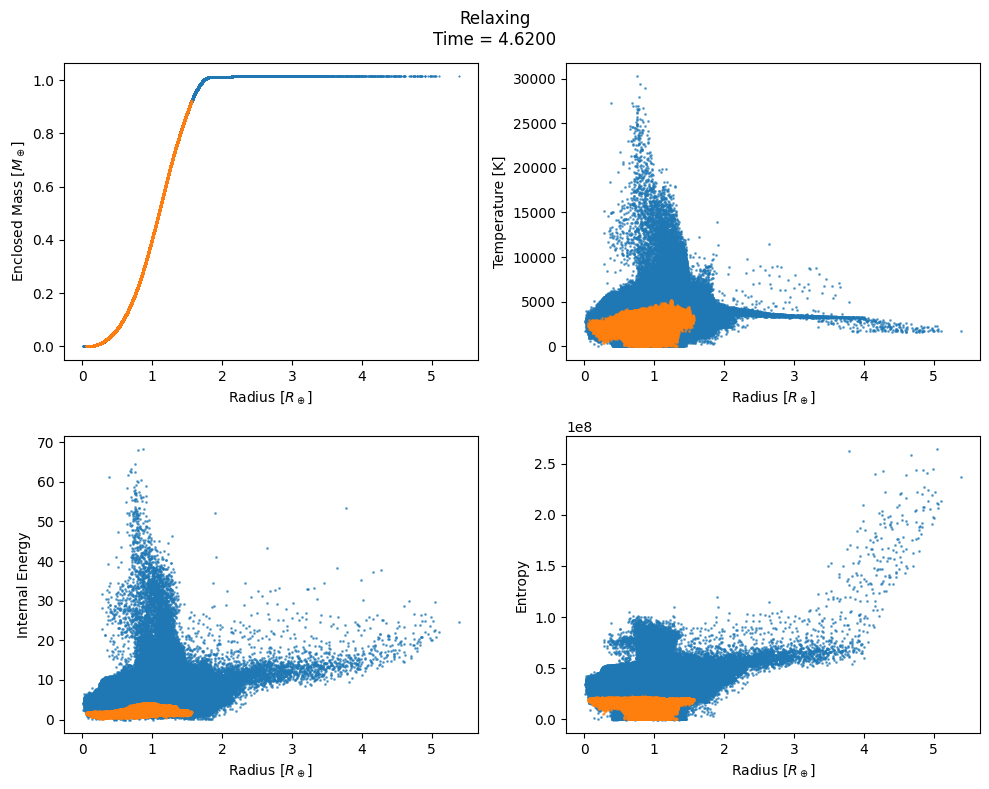

In [10]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import os

R_earth = 6.371e6
M_earth = 5.9724e24
mass_unit = 1/62.46  # GIZMO mass unit
gamma = 1.3          # approximate gamma for silicates/iron

fname = 'n50ic.hdf5'
fname = 'data50ic/snapshot_231.hdf5'

# fname = f"{datadir}/snapshot_{i:03d}.hdf5"

with h5py.File(fname,'r') as f:
    pos = f['/PartType0/Coordinates'][()]   # code units
    m = f['/PartType0/Masses'][()]         # code units
    temp = f['/PartType0/Temperature'][()]
    compid = f['/PartType0/CompositionType'][()]

    entr = f['/PartType0/Entropy'][()]
    u = f['/PartType0/InternalEnergy'][()]
    time = f["Header"].attrs["Time"]
# Convert to physical units
r = np.linalg.norm(pos, axis=1)
m_phys = m * mass_unit    

# Sort by radius for cumulative mass
sort_idx = np.argsort(r)
r_sorted = r[sort_idx]
m_sorted = m_phys[sort_idx]

m_enc = np.cumsum(m_sorted)
unique_comp = np.unique(compid)

# -------- plotting --------
fig, ax = plt.subplots(2, 2, figsize=(10,8))
fig.suptitle(f"Relaxing\nTime = {time:.4f}")

# --- (1) enclosed mass ---
for compi in unique_comp:
    mask = compid[sort_idx] == compi
    ax[0,0].plot(r_sorted[mask], m_enc[mask], '.', ms=1)
ax[0,0].set_xlabel(r"Radius [$R_\oplus]$")
ax[0,0].set_ylabel(r"Enclosed Mass $[M_\oplus]$")

# --- (2) temperature ---
for compi in unique_comp:
    mask = compid == compi
    ax[0,1].scatter(r[mask], temp[mask], s=1, alpha=0.6)

ax[0,1].set_xlabel(r"Radius [$R_\oplus]$")
ax[0,1].set_ylabel("Temperature [K]")

# --- (3) internal energy ---
for compi in unique_comp:
    mask = compid == compi
    ax[1,0].scatter(r[mask], u[mask], s=1, alpha=0.6)

ax[1,0].set_xlabel(r"Radius [$R_\oplus]$")
ax[1,0].set_ylabel("Internal Energy")

# --- (4) entropy ---
for compi in unique_comp:
    mask = compid == compi
    ax[1,1].scatter(r[mask], entr[mask], s=1, alpha=0.6)

ax[1,1].set_xlabel(r"Radius [$R_\oplus]$")
ax[1,1].set_ylabel("Entropy")

# --- limits ---
# for a in ax.flat:
#     a.set_xlim(0, 1.1)

# ax[0,0].set_ylim(0, 0.9)
# ax[0,1].set_ylim(500, 5000)

# # log scale helps a LOT
# ax[1,0].set_yscale('log')
# # ax[1,1].set_yscale('log')

plt.tight_layout()

print(len(pos))

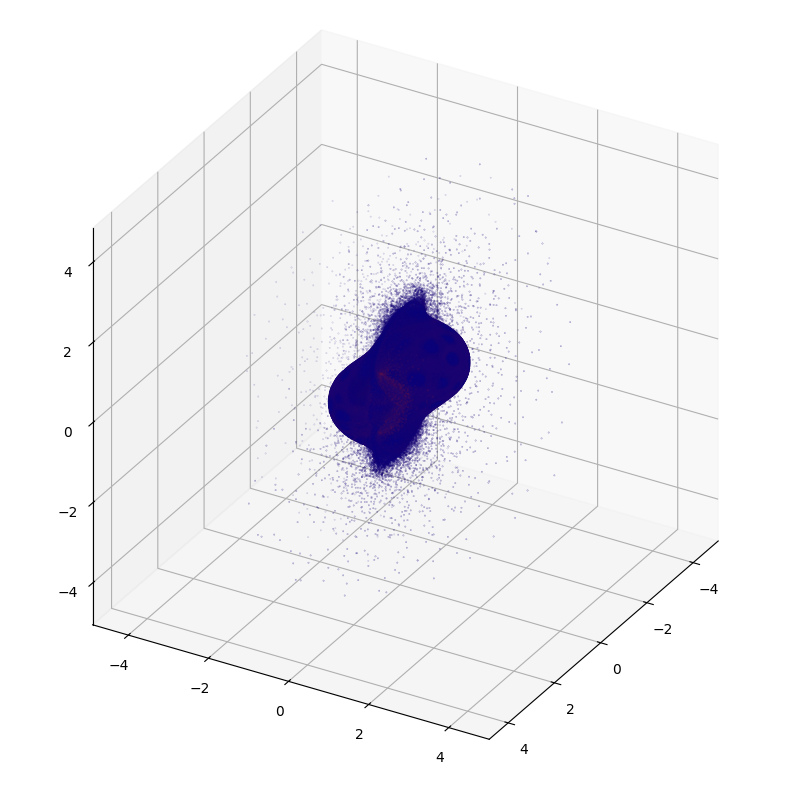

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import Normalize
import h5py
import os

# Define start and end colors
start_color = mcolors.to_rgba('navy')  # 'tab:blue'
end_color = mcolors.to_rgba('firebrick')    # brown

# Create a custom colormap
from matplotlib.colors import LinearSegmentedColormap
custom_cmap = LinearSegmentedColormap.from_list('BlueToBrown', [start_color, end_color])

colorcycle=["#E69F00", "#56B4E9", "#009E73", "#0072B2", "#D55E00", "#CC79A7", "#F0E442"]

# R_earth = 6.371e6
# M_earth = 5.9724e24
# mass_unit = 1/62.46  # GIZMO mass unit
# gamma = 1.3          # approximate gamma for silicates/iron

# fname = 'n50ic.hdf5'
# fname = 'data50ic/snapshot_226.hdf5'
# # fname = f"{datadir}/snapshot_{i:03d}.hdf5"

# with h5py.File(fname,'r') as f:
#     pos = f['/PartType0/Coordinates'][()]   # code units
#     m = f['/PartType0/Masses'][()]         # code units
#     temp = f['/PartType0/Temperature'][()]
#     compid = f['/PartType0/CompositionType'][()]

#     entr = f['/PartType0/Entropy'][()]
#     u = f['/PartType0/InternalEnergy'][()]
#     time = f["Header"].attrs["Time"]
# Original positions
x, y, z = pos[:,0], pos[:,1], pos[:,2]

# Convert to spherical coordinates
r = np.sqrt(x**2 + y**2 + z**2)
theta = np.arccos(z / r)           # polar angle: 0 at north pole
phi = np.arctan2(y, x)             # azimuthal angle: -pi to pi
phi = np.mod(phi, 2*np.pi)         # convert to 0 - 2pi

# Mask out the octant: theta in [0, pi/2], phi in [0, pi/2]
octant_mask = r>0#~((theta >= 0) & (theta <= np.pi/2) & (phi >= 0) & (phi <= np.pi/2))

x_mask = x[octant_mask]
y_mask = y[octant_mask]
z_mask = z[octant_mask]
compid_mask = compid[octant_mask]
temp_mask = temp[octant_mask]

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')

# Camera view parameters
elev, azim = 30, 30
ax.view_init(elev=elev, azim=azim)

# Scatter per component, sorted by distance along camera direction
alphas = np.zeros_like(x_mask)
unique_comp = np.unique(compid)

for i, compi in enumerate(unique_comp):
    comp_indx = compid_mask == compi
    alphas[comp_indx] = 0.6-i*0.3


ax.scatter(x_mask, y_mask, z_mask, c=temp_mask, alpha=alphas, s=0.05, cmap=custom_cmap)

# Equal aspect ratio
max_range = np.array([x_mask.max()-x_mask.min(),
                      y_mask.max()-y_mask.min(),
                      z_mask.max()-z_mask.min()])
max_range_val = max(max_range)/2
mid_x = (x_mask.max()+x_mask.min())*0.5
mid_y = (y_mask.max()+y_mask.min())*0.5
mid_z = (z_mask.max()+z_mask.min())*0.5
ax.set_xlim(mid_x - max_range_val, mid_x + max_range_val)
ax.set_ylim(mid_y - max_range_val, mid_y + max_range_val)
ax.set_zlim(mid_z - max_range_val, mid_z + max_range_val)

ax.set_box_aspect([1,1,1])
ax.set_proj_type('ortho')   # optional but recommended
# ax.set_axis_off()

plt.tight_layout()
plt.show()